In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use Agg backend to avoid issues when running headless
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switching backend for plt if only plt is used

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Enable inline plotting if running in a notebook
%matplotlib inline

# Set plot style for consistency
sns.set(style='whitegrid')


## Data Loading and Preprocessing

In [2]:
# Load the dataset

df = pd.read_csv(r"C:\Users\gaura\Downloads\archive\upi_transactions_2024.csv", encoding='ascii', delimiter=',')

# Display basic information
print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())

# Convert 'timestamp' column to datetime type
# It is important to check for any errors during the datetime conversion
try:
    df['timestamp'] = pd.to_datetime(df['timestamp'], infer_datetime_format=True, errors='raise')
except Exception as e:
    # Other notebook creators may encounter format inconsistencies. Handling errors here is essential.
    print('Error parsing timestamp:', e)

# Display datatypes for verification
print(df.dtypes)

Dataset Shape: (250000, 17)
Columns: ['transaction id', 'timestamp', 'transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend']
transaction id                object
timestamp             datetime64[ns]
transaction type              object
merchant_category             object
amount (INR)                   int64
transaction_status            object
sender_age_group              object
receiver_age_group            object
sender_state                  object
sender_bank                   object
receiver_bank                 object
device_type                   object
network_type                  object
fraud_flag                     int64
hour_of_day                    int64
day_of_week                   object
is_weekend                     int64
dtype: object


## Data Cleaning and Preprocessing

In [3]:
# Check for missing values
print('Missing values per column:\n', df.isnull().sum())

# If missing values are found, one might consider imputation or removal based on context.
# For simplicity, if missing values exist, we will drop rows with missing data.
df.dropna(inplace=True)

# Verify cleaning result
print('Cleaned dataset shape:', df.shape)

# Convert categorical variables to type 'category' for efficient memory usage
categorical_cols = ['transaction id', 'transaction type', 'merchant_category', 'transaction_status',
                    'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
                    'receiver_bank', 'device_type', 'network_type', 'day_of_week']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Quick look at the preprocessed data
print(df.head())

Missing values per column:
 transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64
Cleaned dataset shape: (250000, 17)
  transaction id           timestamp transaction type merchant_category  \
0  TXN0000000001 2024-10-08 15:17:28              P2P     Entertainment   
1  TXN0000000002 2024-04-11 06:56:00              P2M           Grocery   
2  TXN0000000003 2024-04-02 13:27:18              P2P           Grocery   
3  TXN0000000004 2024-01-07 10:09:17              P2P              Fuel   
4  TXN0000000005 2024-01-23 19:04:23              P2P          Shopping   

   amount (INR) transaction_status sender_age_group receiver_age

## Exploratory Data Analysis

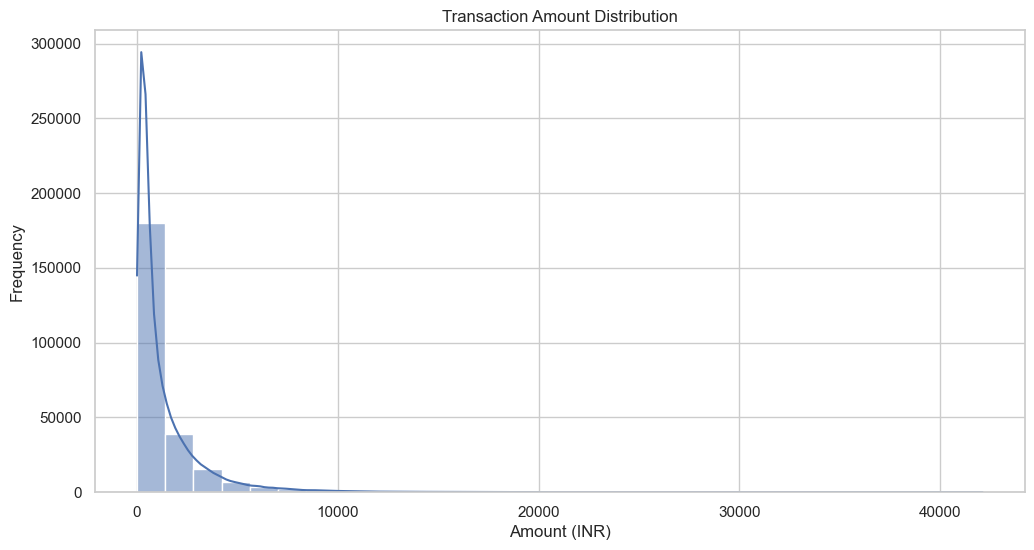

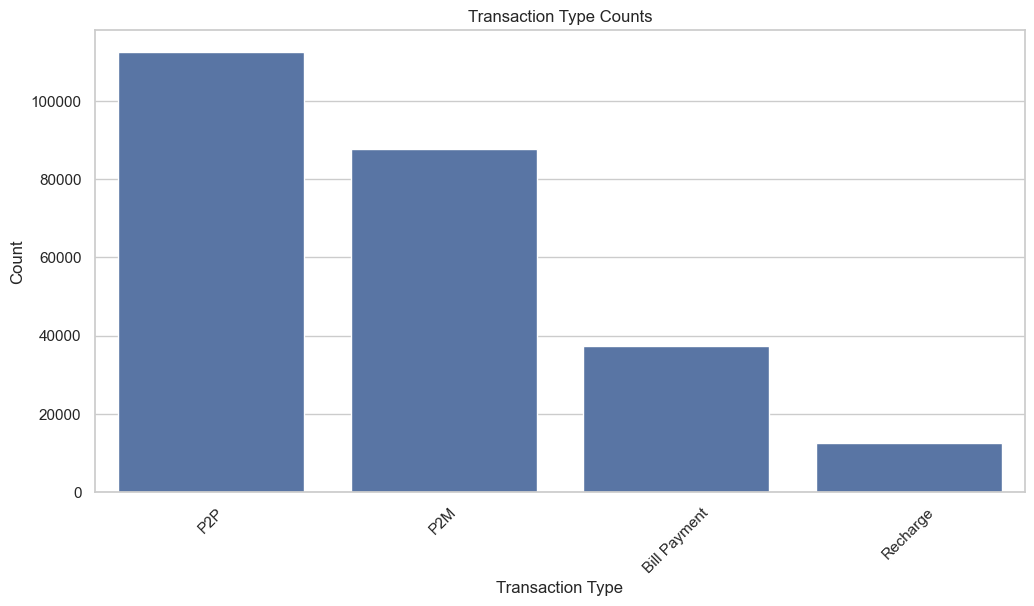

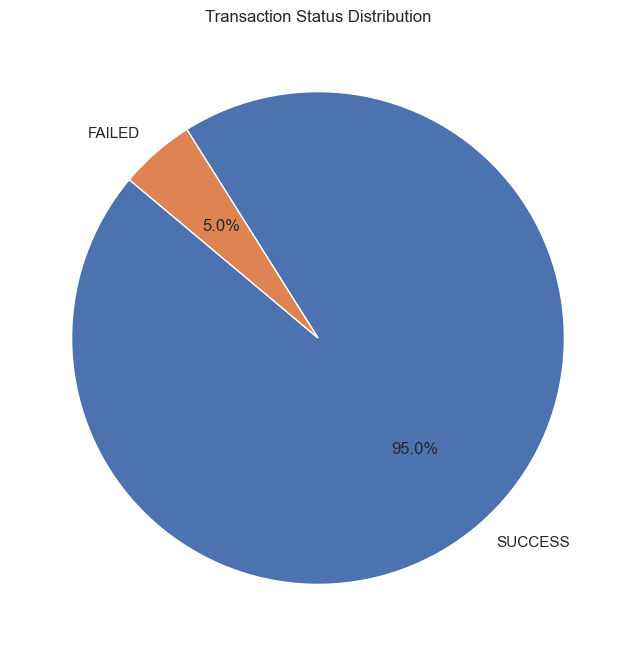

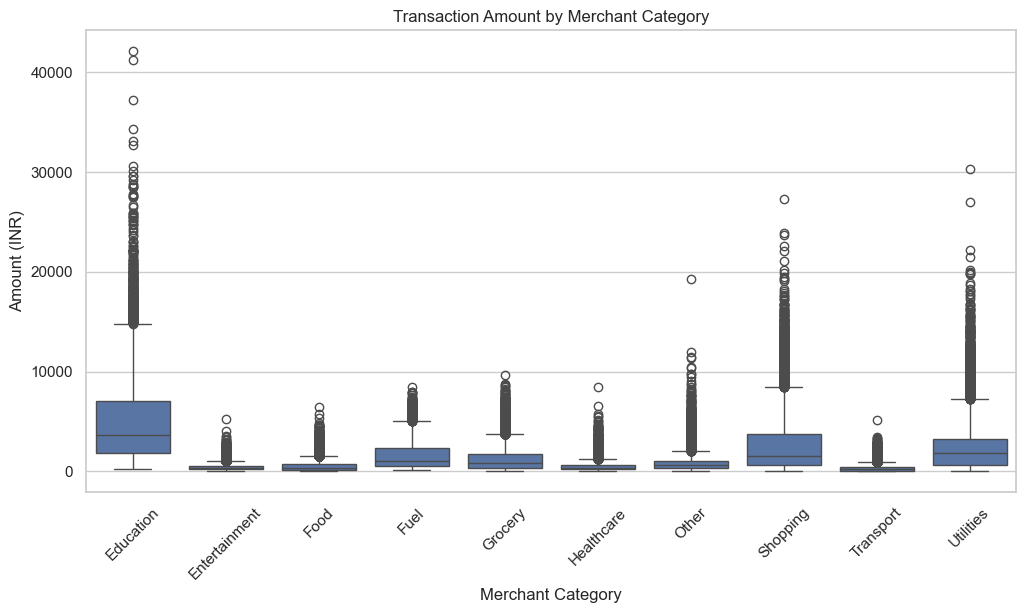

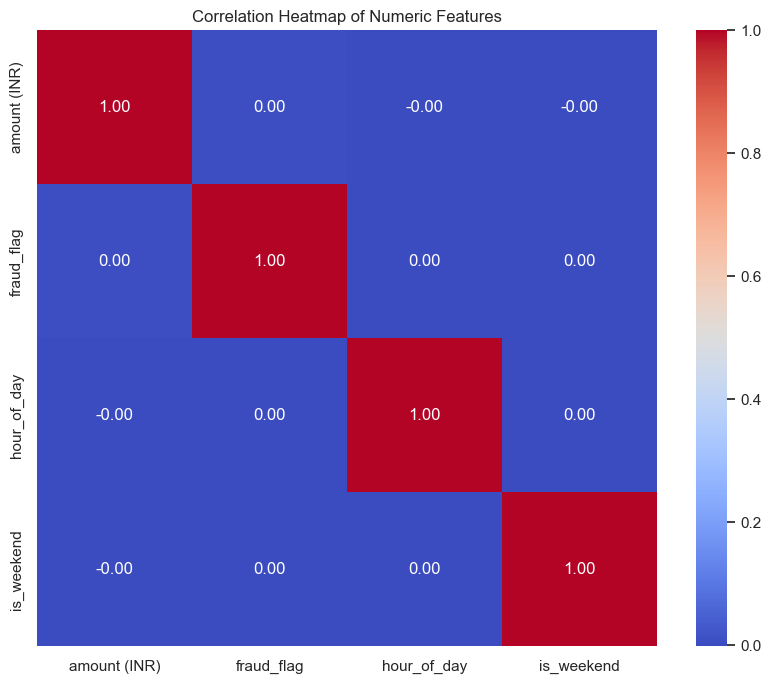

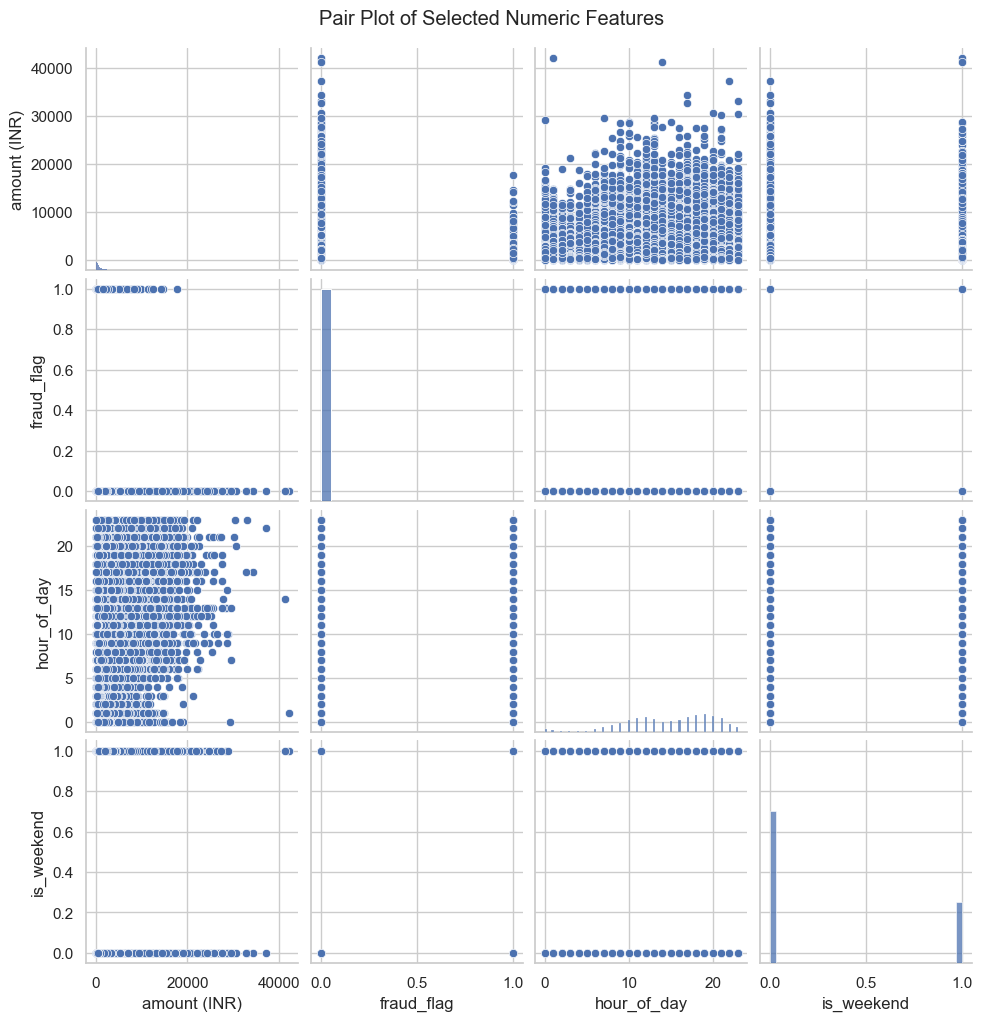

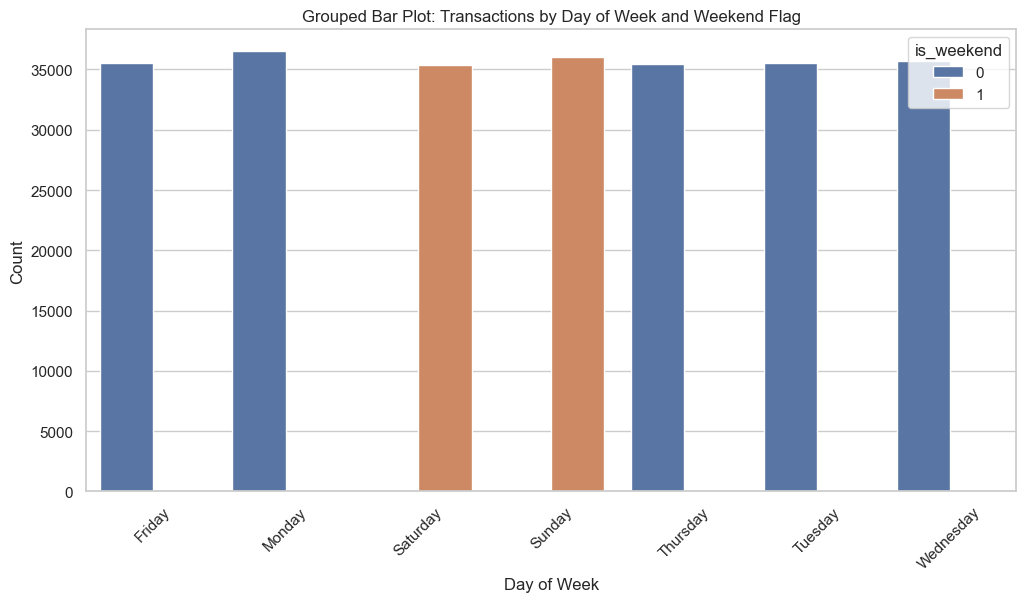

In [4]:
# Plot distributions and various visualizations

# Histogram for the 'amount (INR)' column
plt.figure(figsize=(12, 6))
sns.histplot(df['amount (INR)'], bins=30, kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount (INR)')
plt.ylabel('Frequency')
plt.show()

# Countplot for 'transaction type'
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='transaction type', order=df['transaction type'].value_counts().index)
plt.title('Transaction Type Counts')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Pie Chart using countplot for 'transaction_status'
plt.figure(figsize=(8, 8))
status_counts = df['transaction_status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Transaction Status Distribution')
plt.show()

# Box Plot for transaction amounts by 'merchant_category'
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='merchant_category', y='amount (INR)')
plt.title('Transaction Amount by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=45)
plt.show()

# If there are at least 4 numeric features, generate a correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# Pair Plot on numeric features (amount, fraud_flag, hour_of_day, is_weekend)
if set(['amount (INR)', 'fraud_flag', 'hour_of_day', 'is_weekend']).issubset(numeric_df.columns):
    sns.pairplot(df[['amount (INR)', 'fraud_flag', 'hour_of_day', 'is_weekend']])
    plt.suptitle('Pair Plot of Selected Numeric Features', y=1.02)
    plt.show()

# Grouped Bar Plot: Example: Transaction count by day_of_week and is_weekend
plt.figure(figsize=(12, 6))
grouped = df.groupby(['day_of_week', 'is_weekend']).size().reset_index(name='count')
sns.barplot(data=grouped, x='day_of_week', y='count', hue='is_weekend')
plt.title('Grouped Bar Plot: Transactions by Day of Week and Weekend Flag')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Predictive Modeling

In [ ]:
# In this section, we build a classifier to predict the 'fraud_flag' using the available features.
# This version improves fraud detection by handling class imbalance and tuning the prediction threshold.

df_model = df.copy()

# Drop columns not used for prediction
drop_cols = ['transaction id', 'timestamp']
df_model.drop(columns=drop_cols, inplace=True, errors='ignore')

# Identify features and target
target = 'fraud_flag'
features = df_model.columns.drop(target)

# Encode categorical variables
le = LabelEncoder()
for col in features:
    if df_model[col].dtype.name == 'category' or df_model[col].dtype == object:
        df_model[col] = le.fit_transform(df_model[col])

# Prepare training data
X = df_model[features]
y = df_model[target]

# Stratified split keeps fraud ratio stable in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train imbalance-aware models
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    min_samples_leaf=2
)
rf_clf.fit(X_train, y_train)

# Use ROC-based threshold tuning to avoid predicting only non-fraud
log_reg_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, log_reg_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Predictions
y_pred_log = (log_reg_prob >= optimal_threshold).astype(int)
y_pred_rf = rf_clf.predict(X_test)
rf_prob = rf_clf.predict_proba(X_test)[:, 1]

# Helper for reporting

def print_model_metrics(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0

    print(f"\n{name}")
    print('Confusion Matrix [[TN, FP], [FN, TP]]:', cm.tolist())
    print('Accuracy:', round(accuracy_score(y_true, y_pred), 6))
    print('Precision:', round((tp / (tp + fp)) if (tp + fp) else 0, 6))
    print('Recall:', round((tp / (tp + fn)) if (tp + fn) else 0, 6))
    print('F1-score:', round((2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else 0, 6))
    print('Specificity:', round(specificity, 6))
    print('ROC-AUC:', round(auc(*roc_curve(y_true, y_prob)[:2]), 6))

# Print metrics
print('Logistic Regression optimal threshold:', round(optimal_threshold, 6))
print_model_metrics('Logistic Regression (tuned threshold)', y_test, y_pred_log, log_reg_prob)
print_model_metrics('Random Forest (class-weighted)', y_test, y_pred_rf, rf_prob)

# Plot tuned confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Tuned Threshold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve for Logistic Regression
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc='lower right')
plt.show()



## Conclusion and Future Work

This notebook provided an overview of the UPI Transactions 2024 dataset. We started by cleaning the data and converting date strings into datetime objects. Our exploratory data analysis included various visualizations such as histograms, count plots, box plots, heatmaps, and pair plots to illuminate underlying patterns in the data.

The predictive modeling section demonstrated a basic approach to forecasting fraudulent transactions. While the logistic regression and random forest classifiers offer some insight, there is ample scope for further feature engineering, parameter tuning, and alternative modeling strategies.

Future work might include:
- A deeper exploration of seasonal patterns using the timestamp.
- A more robust feature selection and engineering process based on domain knowledge.
- Exploring more advanced models (e.g., gradient boosting or neural networks) and ensembling methods.

If you appreciated the insights in this notebook, please consider upvoting it. Happy analyzing.